## Desafio 

#### Dessa base de dados (netflix_daily_top_10.csv), analise e extraia:

- Tipos de dados disponíveis
- Período da análise feita
- Tamanho da base de dados
- Verificar dados nulos
- Outliers

In [1]:
import pandas as pd

In [2]:
# Gerar Dataframe
df_netflix = pd.read_csv('./dataset_Desafio/netflix_daily_top_10.csv')

#### Tipo de dados disponíveis e tamanho da base de dados

In [3]:
df_netflix.info()

<class 'pandas.DataFrame'>
RangeIndex: 7100 entries, 0 to 7099
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   As of                 7100 non-null   str  
 1   Rank                  7100 non-null   int64
 2   Year to Date Rank     7100 non-null   str  
 3   Last Week Rank        7100 non-null   str  
 4   Title                 7100 non-null   str  
 5   Type                  7100 non-null   str  
 6   Netflix Exclusive     4599 non-null   str  
 7   Netflix Release Date  7100 non-null   str  
 8   Days In Top 10        7100 non-null   int64
 9   Viewership Score      7100 non-null   int64
dtypes: int64(3), str(7)
memory usage: 554.8 KB


In [4]:
df_netflix.head(5)

,As of,Rank,Year to Date Rank,Last Week Rank,Title,Type,Netflix Exclusive,Netflix Release Date,Days In Top 10,Viewership Score
0,2020-04-01,1,1,1,"Tiger King: Murder, Mayhem …",TV Show,Yes,"Mar 20, 2020",9,90
1,2020-04-01,2,2,-,Ozark,TV Show,Yes,"Jul 21, 2017",5,45
2,2020-04-01,3,3,2,All American,TV Show,NaN,"Mar 28, 2019",9,76
3,2020-04-01,4,4,-,Blood Father,Movie,NaN,"Mar 26, 2020",5,30
4,2020-04-01,5,5,4,The Platform,Movie,Yes,"Mar 20, 2020",9,55


In [5]:
df_netflix.tail(5)

,As of,Rank,Year to Date Rank,Last Week Rank,Title,Type,Netflix Exclusive,Netflix Release Date,Days In Top 10,Viewership Score
7095,2022-03-11,6,5,1,Worst Roommate Ever,TV Show,Yes,"Mar 1, 2022",10,81
7096,2022-03-11,7,7,2,Vikings: Valhalla,TV Show,Yes,"Feb 25, 2022",14,100
7097,2022-03-11,8,8,-,Shooter,Movie,NaN,"Aug 1, 2014",3,7
7098,2022-03-11,9,9,7,Shrek 2,Movie,NaN,"Mar 1, 2022",10,33
7099,2022-03-11,10,10,-,Shrek,Movie,NaN,"May 1, 2018",7,12


In [6]:
df_netflix.describe()

,Rank,Days In Top 10,Viewership Score
count,7100.000000,7100.000000,7100.000000
mean,5.500000,24.123662,122.790141
std,2.872484,58.473789,213.861642
min,1.000000,1.000000,1.000000
25%,3.000000,3.000000,19.000000
50%,5.500000,7.000000,50.000000
75%,8.000000,18.000000,128.000000
max,10.000000,428.000000,1474.000000


## Período da análise feita

In [7]:
import datetime as dt

In [ ]:
# Menor data presente no banco de dados em que foi colhida a informação referente ao filme
inicio = pd.to_datetime(df_netflix['As of']).dt.date.min()
print(inicio)

2020-04-01


In [9]:
# Maior data presente no banco de dados em que foi colhida a informação referente ao filme
fim = pd.to_datetime(df_netflix['As of']).dt.date.max()
print(fim)

2022-03-11


## Verificar Dados nulos

In [11]:
df_netflix.isnull().sum()

As of                      0
Rank                       0
Year to Date Rank          0
Last Week Rank             0
Title                      0
Type                       0
Netflix Exclusive       2501
Netflix Release Date       0
Days In Top 10             0
Viewership Score           0
dtype: int64

In [12]:
df_netflix['Netflix Exclusive'].value_counts()

Netflix Exclusive
Yes    4599
Name: count, dtype: int64

Vejo que o campo Netflix Exclusive tem como dado Yes e null, talvez seria melhor colocar como yes e no, para ter mais sentido, já que o filme é ou não é exclusivo da netflix

In [18]:
df_netflix.fillna('No')
# Para aplicar teria o inplace=True

,As of,Rank,Year to Date Rank,Last Week Rank,Title,Type,Netflix Exclusive,Netflix Release Date,Days In Top 10,Viewership Score
0,2020-04-01,1,1,1,"Tiger King: Murder, Mayhem …",TV Show,Yes,"Mar 20, 2020",9,90
1,2020-04-01,2,2,-,Ozark,TV Show,Yes,"Jul 21, 2017",5,45
2,2020-04-01,3,3,2,All American,TV Show,No,"Mar 28, 2019",9,76
3,2020-04-01,4,4,-,Blood Father,Movie,No,"Mar 26, 2020",5,30
4,2020-04-01,5,5,4,The Platform,Movie,Yes,"Mar 20, 2020",9,55
...,...,...,...,...,...,...,...,...,...,...
7095,2022-03-11,6,5,1,Worst Roommate Ever,TV Show,Yes,"Mar 1, 2022",10,81
7096,2022-03-11,7,7,2,Vikings: Valhalla,TV Show,Yes,"Feb 25, 2022",14,100
7097,2022-03-11,8,8,-,Shooter,Movie,No,"Aug 1, 2014",3,7
7098,2022-03-11,9,9,7,Shrek 2,Movie,No,"Mar 1, 2022",10,33


## Outliers

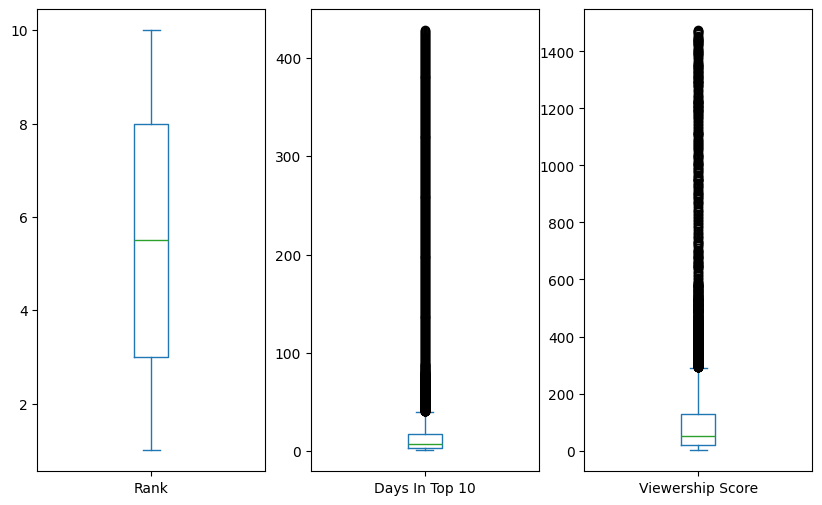

In [22]:
df_netflix.plot(kind='box',figsize=(10,6),subplots=True); 

Tem bastante outliers no "Days In Top 10" e "Viewership Score"

#### Inicio do cenário onde eu retiro os valores nulos

In [24]:
df_netflix_noNull = df_netflix.dropna(axis=0)

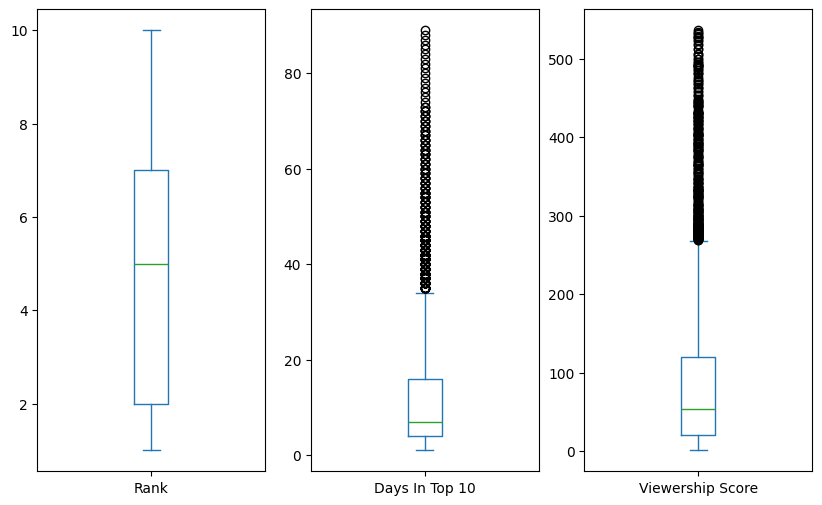

In [25]:
df_netflix_noNull.plot(kind='box',figsize=(10,6),subplots=True); 

Vou Seguir com todos os valores mesmo, só criei o cenario onde eu retiro os valores nulos para servir de teste

In [26]:
df_netflix[df_netflix['Days In Top 10'] >= 100]

,As of,Rank,Year to Date Rank,Last Week Rank,Title,Type,Netflix Exclusive,Netflix Release Date,Days In Top 10,Viewership Score
2886,2021-01-14,7,6,8,Cocomelon,TV Show,NaN,"Jun 1, 2020",100,287
2896,2021-01-15,7,7,10,Cocomelon,TV Show,NaN,"Jun 1, 2020",101,291
2909,2021-01-16,10,7,9,Cocomelon,TV Show,NaN,"Jun 1, 2020",102,292
2919,2021-01-17,10,10,9,Cocomelon,TV Show,NaN,"Jun 1, 2020",103,293
3019,2021-01-27,10,-,-,Cocomelon,TV Show,NaN,"Jun 1, 2020",104,294
...,...,...,...,...,...,...,...,...,...,...
6674,2022-01-28,5,6,-,Cocomelon,TV Show,NaN,"Jun 1, 2020",424,1466
6687,2022-01-29,8,5,8,Cocomelon,TV Show,NaN,"Jun 1, 2020",425,1469
6718,2022-02-01,9,-,7,Cocomelon,TV Show,NaN,"Jun 1, 2020",426,1471
6959,2022-02-25,10,-,-,Cocomelon,TV Show,NaN,"Jun 1, 2020",427,1472


So vejo o titulo (Title) de Cocomelon e tipo/genero (Type) TV Show, quero saber os títulos de mais alguns que estão presentes aqui

In [29]:
df_netflix.Title.value_counts()

Title
Cocomelon                       428
Ozark                            85
Cobra Kai                        81
Manifest                         80
The Queenâs Gambit             73
                               ... 
Scary Stories to Tell in th…      1
Dark Shadows                      1
Chosen                            1
The Lucky One                     1
Fistful of Vengeance              1
Name: count, Length: 645, dtype: int64

In [30]:
df_netflix.Type.value_counts()

Type
TV Show            4446
Movie              2611
Stand-Up Comedy      41
Concert/Perf…         2
Name: count, dtype: int64

<Axes: >

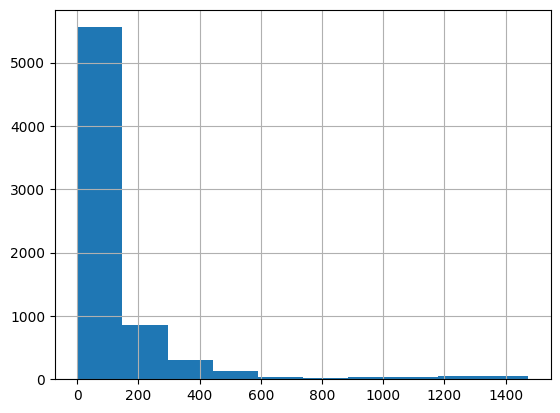

In [31]:
df_netflix['Viewership Score'].hist()

In [ ]:
# Achar a maior nota ou o maior outlier
df_netflix[df_netflix['Viewership Score'] == df_netflix['Viewership Score'].max()]

,As of,Rank,Year to Date Rank,Last Week Rank,Title,Type,Netflix Exclusive,Netflix Release Date,Days In Top 10,Viewership Score
6998,2022-03-01,9,-,-,Cocomelon,TV Show,NaN,"Jun 1, 2020",428,1474
